In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import pandas as pd

In [1]:
sentences = [
    "Artificial Intelligence is transforming healthcare.",
    "AI is changing medical diagnosis.",
    "Football is a popular sport.",
    "Hospitals use machine learning."
]

In [ ]:
model = SentenceTransformer("all-MiniLM-L6-v2")

NameError: name 'SentenceTransformer' is not defined

In [ ]:
embeddings = model.encode(sentences)

print("Embedding Shape:", embeddings.shape)

Embedding Shape: (4, 384)


In [ ]:
similarity = cosine_similarity(embeddings)

df = pd.DataFrame(similarity,
                  index=sentences,
                  columns=sentences)

print(df.round(2))

                                                    Artificial Intelligence is transforming healthcare.  \
Artificial Intelligence is transforming healthc...                                               1.00     
AI is changing medical diagnosis.                                                                0.74     
Football is a popular sport.                                                                     0.12     
Hospitals use machine learning.                                                                  0.60     

                                                    AI is changing medical diagnosis.  \
Artificial Intelligence is transforming healthc...                               0.74   
AI is changing medical diagnosis.                                                1.00   
Football is a popular sport.                                                     0.04   
Hospitals use machine learning.                                                  0.50   

                  

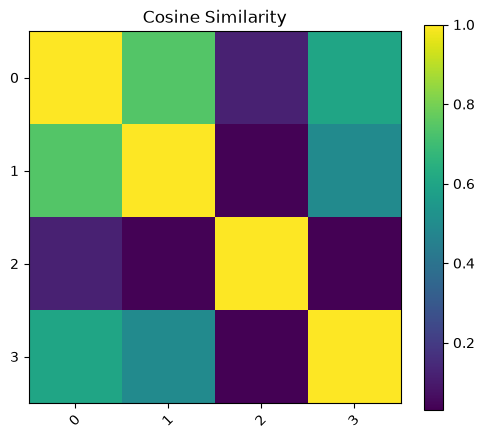

In [ ]:
plt.figure(figsize=(6,5))
plt.imshow(similarity)
plt.colorbar()
plt.xticks(range(len(sentences)), range(len(sentences)), rotation=45)
plt.yticks(range(len(sentences)), range(len(sentences)))
plt.title("Cosine Similarity")
plt.show()

In [ ]:
query = "Machine learning in hospitals"

query_embedding = model.encode([query])

scores = cosine_similarity(query_embedding, embeddings)[0]

ranking = pd.DataFrame({
    "Sentence": sentences,
    "Similarity": scores
})

ranking.sort_values("Similarity", ascending=False)

,Sentence,Similarity
3,Hospitals use machine learning.,0.918684
0,Artificial Intelligence is transforming health...,0.547796
1,AI is changing medical diagnosis.,0.473808
2,Football is a popular sport.,-0.011591


In [ ]:
print("""
Observations:
- Higher cosine similarity indicates higher semantic similarity.
- AI-related sentences are closer in vector space.
- Football sentence is least similar.
- Embeddings can be used for semantic search and RAG retrieval.
""")


Observations:
- Higher cosine similarity indicates higher semantic similarity.
- AI-related sentences are closer in vector space.
- Football sentence is least similar.
- Embeddings can be used for semantic search and RAG retrieval.

